# Trabajo práctico número 4
## Grupo 2

#Carga de bibliotecas

In [ ]:
pip install fitter

In [ ]:
from fitter import Fitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Carga de datos

In [ ]:
datos = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TP4-SImulacion/Datos/hospital_data_sampleee.xlsx')

#Analisis

In [ ]:
type(datos)

pandas.DataFrame

###CONTENIDO:
#####Date : Dia de la visita
#####Medication Revenue : Ganancia de la medicacion
#####Lab Cost : Costos de laboratorio pagado por el paciente
#####Consultation Revenue : Ganancia de la consulta
#####Doctor Type : Especialidad del doctor
#####Financial Class : Tipo de cobertura medica. [INSURANCE, PRIVATE, CORPORATE, HMO, MEDICARE]
#####Patient Type : OUTPATIENT, paciente sin internacion. Todos los registros
#####Entry Time : Hora de entrada al hospital
#####Post-Consultation Time : Hora de entrada a la consulta
#####Completion Time : Hora de salida del paciente
#####Patient ID : ID

In [ ]:
datos.head()

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID
0,2019-11-04,1183.22,10,20.17,ANCHOR,HMO,OUTPATIENT,08:35:45,09:17:54,09:29:46,C10001
1,2019-11-06,738.48,$-,15,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,C10002
2,2019-11-02,660,$-,21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,C10003
3,2019-11-06,600,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,09:38:34,10:55:50,10:58:02,C10004
4,2019-11-01,591.6,$-,12,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,C10005


In [ ]:
datos.shape

(29998, 11)

In [ ]:
datos.dtypes

Date                      datetime64[us]
 Medication Revenue               object
  Lab Cost                        object
 Consultation Revenue             object
Doctor Type                          str
Financial Class                      str
Patient Type                         str
Entry Time                        object
Post-Consultation Time            object
Completion Time                   object
Patient ID                           str
dtype: object

In [ ]:
datos["Doctor Type"].value_counts()

Doctor Type
ANCHOR      21913
LOCUM        6789
FLOATING     1296
Name: count, dtype: int64

####Tipo de medico:
#####Buscando el significado de ANCHOR, LOCUM, FLOATING entendemos que estos son medicos Titulares, Sustituto, Voluntario.

In [ ]:
datos["Date"].value_counts()

Date
2019-11-11    3617
2019-11-04    3365
2019-11-12    2892
2019-11-06    2813
2019-11-05    2798
2019-11-07    2673
2019-11-01    2518
2019-11-08    2405
2019-11-09    1539
2019-11-02    1471
2019-11-13    1358
2019-11-03    1301
2019-11-10    1248
Name: count, dtype: int64

####Fechas
#####Las fechas corresponden a los primeros 13 dias de noviembre. Por lo tanto no tendremos discriminacion en cuanto a la fecha para crear diferentes variables aleatorias.
#####Aunque cabe remarcar que a excepcion del 13/11 los cuatro dias con menos pacientes atendidos corresponden a los dias sabado y domingo. Mientras que los dos dias con mas pacientes corresponden a un dia lunes.


#Preparación de datos


####Empezamos juntando la fecha a cada horario dejandolos en datetime.

In [ ]:
datos['Entry_Time_datetime'] = datos["Date"] + pd.to_timedelta(datos["Entry Time"].astype(str))

In [ ]:
datos['Post_Consultation_Time_datetime'] = datos["Date"] + pd.to_timedelta(datos["Post-Consultation Time"].astype(str))


In [ ]:
datos['Completion_Time_datetime'] = datos["Date"] + pd.to_timedelta(datos["Completion Time"].astype(str))

#####Chequeamos valores obtenidos.

In [ ]:
datos.head()

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID,Entry_Time_datetime,Post_Consultation_Time_datetime,Completion_Time_datetime
0,2019-11-04,1183.22,10,20.17,ANCHOR,HMO,OUTPATIENT,08:35:45,09:17:54,09:29:46,C10001,2019-11-04 08:35:45,2019-11-04 09:17:54,2019-11-04 09:29:46
1,2019-11-06,738.48,$-,15,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,C10002,2019-11-06 19:19:16,2019-11-06 21:02:36,2019-11-06 21:24:07
2,2019-11-02,660,$-,21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,C10003,2019-11-02 10:46:52,2019-11-02 11:56:25,2019-11-02 12:06:28
3,2019-11-06,600,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,09:38:34,10:55:50,10:58:02,C10004,2019-11-06 09:38:34,2019-11-06 10:55:50,2019-11-06 10:58:02
4,2019-11-01,591.6,$-,12,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,C10005,2019-11-01 11:16:21,2019-11-01 12:06:49,2019-11-01 12:06:54


In [ ]:
datos['Tiempo_consulta'] = datos['Completion_Time_datetime']-datos['Post_Consultation_Time_datetime']

In [ ]:
datos.dtypes

Date                                datetime64[us]
 Medication Revenue                         object
  Lab Cost                                  object
 Consultation Revenue                       object
Doctor Type                                    str
Financial Class                                str
Patient Type                                   str
Entry Time                                  object
Post-Consultation Time                      object
Completion Time                             object
Patient ID                                     str
Entry_Time_datetime                 datetime64[us]
Post_Consultation_Time_datetime     datetime64[us]
Completion_Time_datetime            datetime64[us]
Tiempo_consulta                    timedelta64[us]
dtype: object

#####Creamos valores de tiempo de consulta en segundos y minutos.

In [ ]:
datos['Tiempo_consulta_seg']=datos.Tiempo_consulta.dt.total_seconds()

In [ ]:
datos['Tiempo_consulta_min']=datos.Tiempo_consulta_seg / 60

#####Filtramos consultas en medicos titulares y sustitutos.

In [ ]:
datos_titulares = datos[datos['Doctor Type'] == "ANCHOR"]

In [ ]:
datos_sustitutos = datos[datos['Doctor Type'] == "LOCUM"]

#####Chequeamos variables creadas

In [ ]:
datos_titulares.head()

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID,Entry_Time_datetime,Post_Consultation_Time_datetime,Completion_Time_datetime,Tiempo_consulta,Tiempo_consulta_seg,Tiempo_consulta_min
0,2019-11-04,1183.22,10,20.17,ANCHOR,HMO,OUTPATIENT,08:35:45,09:17:54,09:29:46,C10001,2019-11-04 08:35:45,2019-11-04 09:17:54,2019-11-04 09:29:46,0 days 00:11:52,712.0,11.866667
1,2019-11-06,738.48,$-,15,ANCHOR,INSURANCE,OUTPATIENT,19:19:16,21:02:36,21:24:07,C10002,2019-11-06 19:19:16,2019-11-06 21:02:36,2019-11-06 21:24:07,0 days 00:21:31,1291.0,21.516667
2,2019-11-02,660,$-,21.17,ANCHOR,HMO,OUTPATIENT,10:46:52,11:56:25,12:06:28,C10003,2019-11-02 10:46:52,2019-11-02 11:56:25,2019-11-02 12:06:28,0 days 00:10:03,603.0,10.050000
3,2019-11-06,600,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,09:38:34,10:55:50,10:58:02,C10004,2019-11-06 09:38:34,2019-11-06 10:55:50,2019-11-06 10:58:02,0 days 00:02:12,132.0,2.200000
4,2019-11-01,591.6,$-,12,ANCHOR,INSURANCE,OUTPATIENT,11:16:21,12:06:49,12:06:54,C10005,2019-11-01 11:16:21,2019-11-01 12:06:49,2019-11-01 12:06:54,0 days 00:00:05,5.0,0.083333


In [ ]:
datos_titulares.shape

(21913, 17)

In [ ]:
datos_sustitutos.head()

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID,Entry_Time_datetime,Post_Consultation_Time_datetime,Completion_Time_datetime,Tiempo_consulta,Tiempo_consulta_seg,Tiempo_consulta_min
5,2019-11-04,586.8,$-,13,LOCUM,INSURANCE,OUTPATIENT,19:22:09,20:14:03,20:15:03,C10006,2019-11-04 19:22:09,2019-11-04 20:14:03,2019-11-04 20:15:03,0 days 00:01:00,60.0,1.000000
9,2019-11-02,468.02,10,23.91,LOCUM,HMO,OUTPATIENT,10:01:25,10:32:38,10:35:17,C10010,2019-11-02 10:01:25,2019-11-02 10:32:38,2019-11-02 10:35:17,0 days 00:02:39,159.0,2.650000
16,2019-11-09,425.85,$-,30,LOCUM,INSURANCE,OUTPATIENT,20:55:38,21:45:11,21:51:25,C10017,2019-11-09 20:55:38,2019-11-09 21:45:11,2019-11-09 21:51:25,0 days 00:06:14,374.0,6.233333
32,2019-11-05,355.47,$-,12,LOCUM,INSURANCE,OUTPATIENT,08:02:59,11:28:44,11:28:48,C10033,2019-11-05 08:02:59,2019-11-05 11:28:44,2019-11-05 11:28:48,0 days 00:00:04,4.0,0.066667
35,2019-11-02,342.02,$-,23.91,LOCUM,HMO,OUTPATIENT,09:10:04,09:30:44,09:36:21,C10036,2019-11-02 09:10:04,2019-11-02 09:30:44,2019-11-02 09:36:21,0 days 00:05:37,337.0,5.616667


In [ ]:
datos_sustitutos.shape

(6789, 17)

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

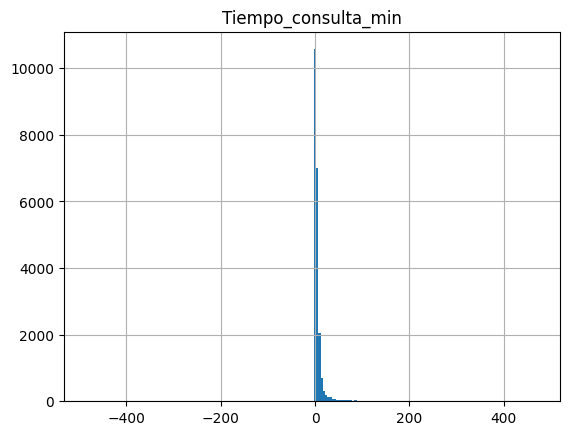

In [ ]:
datos_titulares.hist('Tiempo_consulta_min',bins=200)

<Axes: >

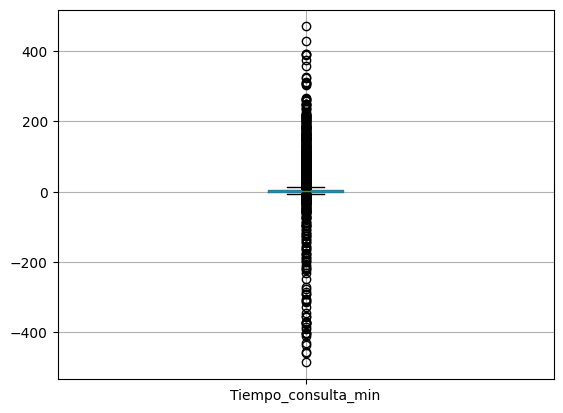

In [ ]:
datos_titulares.boxplot('Tiempo_consulta_min')

In [ ]:
datos_titulares = datos_titulares.sort_values('Tiempo_consulta_min')

In [ ]:
datos_titulares.head(400)

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID,Entry_Time_datetime,Post_Consultation_Time_datetime,Completion_Time_datetime,Tiempo_consulta,Tiempo_consulta_seg,Tiempo_consulta_min
28356,2019-11-12,$-,25,$-,ANCHOR,PRIVATE,OUTPATIENT,08:31:21,16:59:42,08:54:38,C38358,2019-11-12 08:31:21,2019-11-12 16:59:42,2019-11-12 08:54:38,-1 days +15:54:56,-29104.0,-485.066667
21545,2019-11-05,$-,75,25.24,ANCHOR,PRIVATE,OUTPATIENT,08:36:21,16:48:40,09:11:15,C31546,2019-11-05 08:36:21,2019-11-05 16:48:40,2019-11-05 09:11:15,-1 days +16:22:35,-27445.0,-457.416667
29477,2019-11-13,$-,25,$-,ANCHOR,PRIVATE,OUTPATIENT,08:30:52,16:31:22,08:54:41,C39479,2019-11-13 08:30:52,2019-11-13 16:31:22,2019-11-13 08:54:41,-1 days +16:23:19,-27401.0,-456.683333
12431,2019-11-08,18.74,$-,12,ANCHOR,INSURANCE,OUTPATIENT,09:05:34,16:56:56,09:40:23,C22432,2019-11-08 09:05:34,2019-11-08 16:56:56,2019-11-08 09:40:23,-1 days +16:43:27,-26193.0,-436.550000
27085,2019-11-11,$-,115,$-,ANCHOR,PRIVATE,OUTPATIENT,08:35:35,16:30:09,09:19:18,C37086,2019-11-11 08:35:35,2019-11-11 16:30:09,2019-11-11 09:19:18,-1 days +16:49:09,-25851.0,-430.850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11165,2019-11-04,21.23,$-,12,ANCHOR,INSURANCE,OUTPATIENT,08:42:26,09:05:34,09:05:35,C21166,2019-11-04 08:42:26,2019-11-04 09:05:34,2019-11-04 09:05:35,0 days 00:00:01,1.0,0.016667
11150,2019-11-09,21.25,$-,28,ANCHOR,INSURANCE,OUTPATIENT,10:20:06,11:35:17,11:35:18,C21151,2019-11-09 10:20:06,2019-11-09 11:35:17,2019-11-09 11:35:18,0 days 00:00:01,1.0,0.016667
27994,2019-11-11,$-,$-,$-,ANCHOR,MEDICARE,OUTPATIENT,18:07:19,18:29:32,18:29:33,C37995,2019-11-11 18:07:19,2019-11-11 18:29:32,2019-11-11 18:29:33,0 days 00:00:01,1.0,0.016667
11590,2019-11-12,20.43,$-,13,ANCHOR,INSURANCE,OUTPATIENT,14:12:41,15:04:00,15:04:01,C21591,2019-11-12 14:12:41,2019-11-12 15:04:00,2019-11-12 15:04:01,0 days 00:00:01,1.0,0.016667


#####En este caso vemos que la salida del hospital sucede antes de la entrada a la clinica, consideraremos estos casos como arrepentidos.

#####Procederemos a filtrar los datos.

In [ ]:
datos_titulares_filtrados = datos_titulares[datos_titulares['Tiempo_consulta_min'] > 0]

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

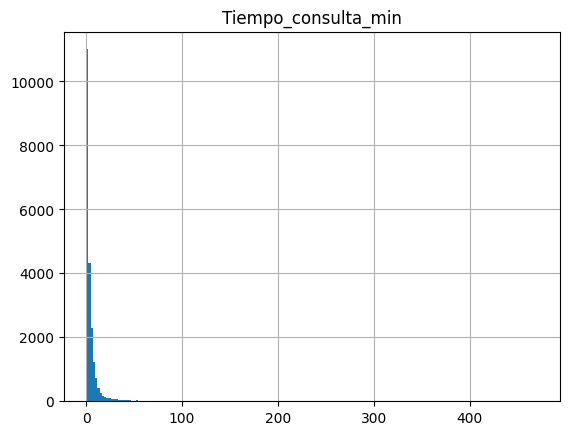

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

<Axes: >

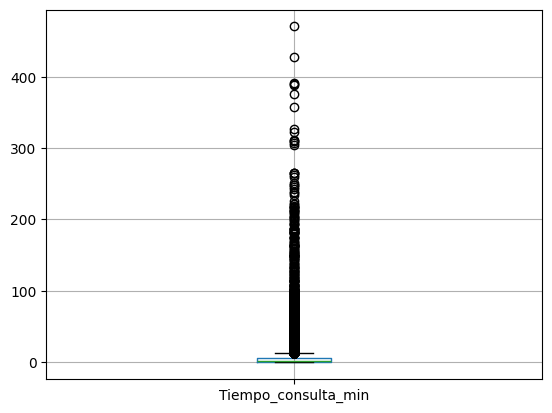

In [ ]:
datos_titulares_filtrados.boxplot('Tiempo_consulta_min')

Procederemos a acotar los tiempos.

In [ ]:
datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 300]

/tmp/ipykernel_1400/4005334298.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 300]


array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

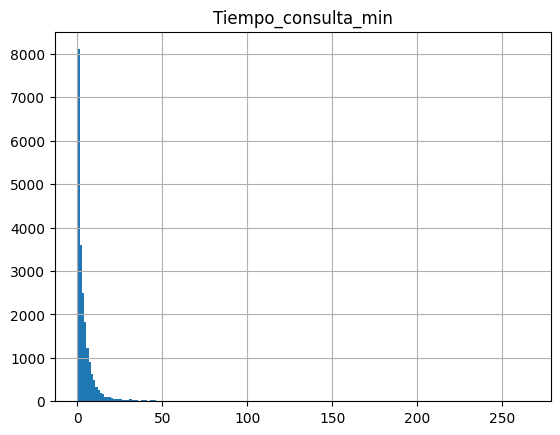

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

<Axes: >

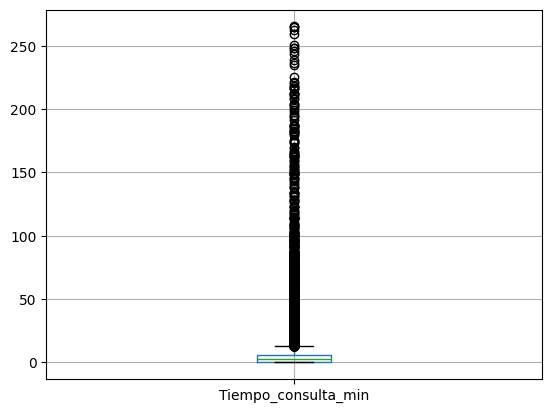

In [ ]:
datos_titulares_filtrados.boxplot('Tiempo_consulta_min')

In [ ]:
datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 100]

/tmp/ipykernel_1400/3242405494.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 100]


array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

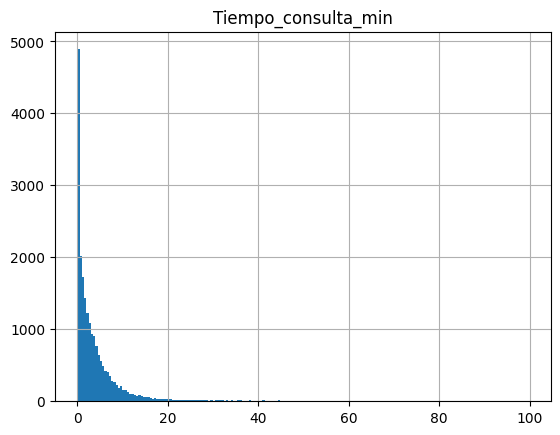

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

<Axes: >

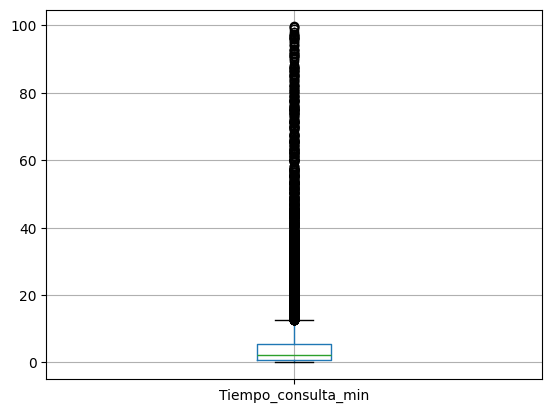

In [ ]:
datos_titulares_filtrados.boxplot('Tiempo_consulta_min')

In [ ]:
datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 40]

/tmp/ipykernel_1400/1577735202.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 40]


array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

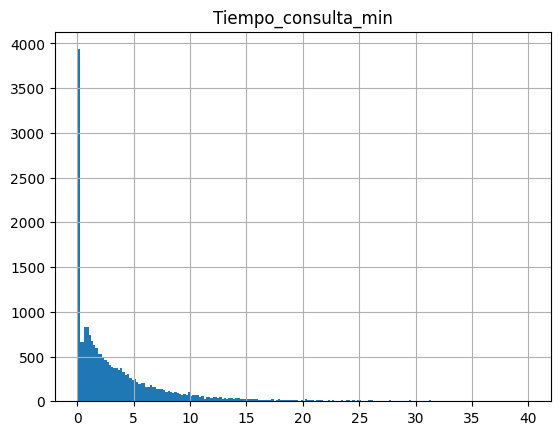

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

<Axes: >

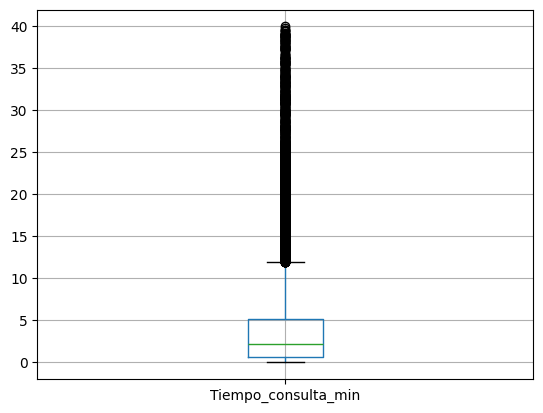

In [ ]:
datos_titulares_filtrados.boxplot('Tiempo_consulta_min')

In [ ]:
datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 25]

/tmp/ipykernel_1400/2364502674.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] < 25]


array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

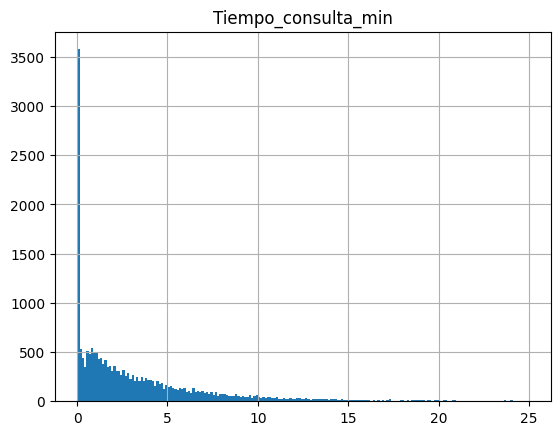

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

<Axes: >

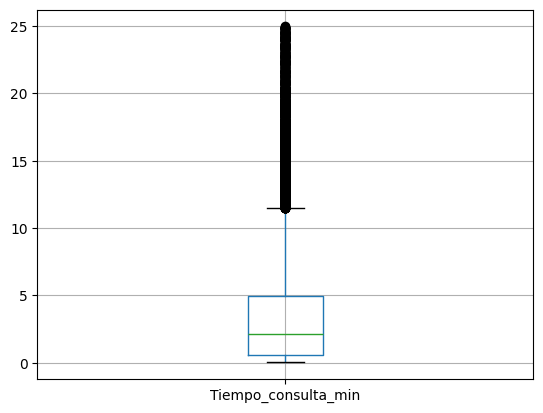

In [ ]:
datos_titulares_filtrados.boxplot('Tiempo_consulta_min')

#####Conderamos que el pico en Tiempo = 0 corresponde a un error en como se mide el tiempo de los medicos, por lo que lo eliminaremos. Ejemplo, no se registra cuando entra el paciente a consulta y se marca la entrada y salida al mismo tiempo

In [ ]:
datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] > 1]

/tmp/ipykernel_1400/503486294.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  datos_titulares_filtrados = datos_titulares_filtrados[datos_titulares['Tiempo_consulta_min'] > 1]


array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

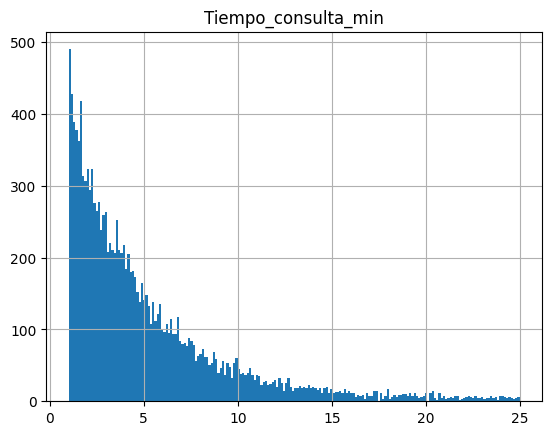

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

#####Tomaremos estos tiempos para el calculo del Tiempo de atención.

####Procedemos a hacer lo mismo para los tiempos de atencion de medicos Sustitutos.

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

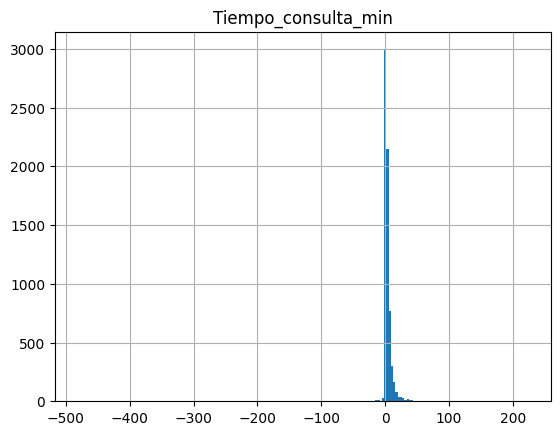

In [ ]:
datos_sustitutos.hist('Tiempo_consulta_min',bins=200)

In [ ]:
datos_sustitutos_filtrados = datos_sustitutos[(datos_sustitutos['Tiempo_consulta_min'] > 1)&(datos_sustitutos['Tiempo_consulta_min'] < 25)]

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

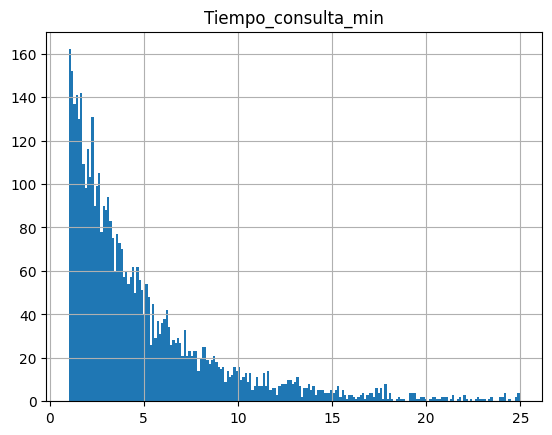

In [ ]:
datos_sustitutos_filtrados.hist('Tiempo_consulta_min',bins=200)

####Ahora obtendremos nuestros datos filtrados para los arribos.

In [ ]:
datos = datos.sort_values('Entry_Time_datetime')

In [ ]:
datos['Intervalo_arribos']=datos['Entry_Time_datetime'].diff()

In [ ]:
datos['Intervalo_arribos_min']=datos.Intervalo_arribos.dt.total_seconds() / 60

In [ ]:
datos.head(400)

,Date,Medication Revenue,Lab Cost,Consultation Revenue,Doctor Type,Financial Class,Patient Type,Entry Time,Post-Consultation Time,Completion Time,Patient ID,Entry_Time_datetime,Post_Consultation_Time_datetime,Completion_Time_datetime,Tiempo_consulta,Tiempo_consulta_seg,Tiempo_consulta_min,Intervalo_arribos,Intervalo_arribos_min
9732,2019-11-01,24,$-,18.3,ANCHOR,HMO,OUTPATIENT,08:00:37,09:11:33,09:13:31,C19733,2019-11-01 08:00:37,2019-11-01 09:11:33,2019-11-01 09:13:31,0 days 00:01:58,118.0,1.966667,NaT,NaN
5939,2019-11-01,33.7,$-,18.3,ANCHOR,HMO,OUTPATIENT,08:01:03,08:19:22,08:21:08,C15940,2019-11-01 08:01:03,2019-11-01 08:19:22,2019-11-01 08:21:08,0 days 00:01:46,106.0,1.766667,0 days 00:00:26,0.433333
255,2019-11-01,159,27,$-,ANCHOR,MEDICARE,OUTPATIENT,08:01:18,08:58:40,08:58:51,C10256,2019-11-01 08:01:18,2019-11-01 08:58:40,2019-11-01 08:58:51,0 days 00:00:11,11.0,0.183333,0 days 00:00:15,0.250000
11552,2019-11-01,20.5,$-,8,ANCHOR,CORPORATE,OUTPATIENT,08:01:26,08:29:42,08:29:44,C21553,2019-11-01 08:01:26,2019-11-01 08:29:42,2019-11-01 08:29:44,0 days 00:00:02,2.0,0.033333,0 days 00:00:08,0.133333
919,2019-11-01,86.41,$-,24.3,ANCHOR,MEDICARE,OUTPATIENT,08:01:33,08:31:22,08:32:20,C10920,2019-11-01 08:01:33,2019-11-01 08:31:22,2019-11-01 08:32:20,0 days 00:00:58,58.0,0.966667,0 days 00:00:07,0.116667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14752,2019-11-01,14,$-,15,ANCHOR,CORPORATE,OUTPATIENT,09:20:48,09:43:49,09:51:03,C24753,2019-11-01 09:20:48,2019-11-01 09:43:49,2019-11-01 09:51:03,0 days 00:07:14,434.0,7.233333,0 days 00:00:20,0.333333
18200,2019-11-01,$-,$-,$-,ANCHOR,PRIVATE,OUTPATIENT,09:20:59,09:40:05,09:51:08,C28201,2019-11-01 09:20:59,2019-11-01 09:40:05,2019-11-01 09:51:08,0 days 00:11:03,663.0,11.050000,0 days 00:00:11,0.183333
375,2019-11-01,133.61,$-,$-,ANCHOR,HMO,OUTPATIENT,09:21:21,09:36:02,09:44:13,C10376,2019-11-01 09:21:21,2019-11-01 09:36:02,2019-11-01 09:44:13,0 days 00:08:11,491.0,8.183333,0 days 00:00:22,0.366667
18201,2019-11-01,$-,$-,$-,ANCHOR,PRIVATE,OUTPATIENT,09:21:22,10:02:37,10:03:20,C28202,2019-11-01 09:21:22,2019-11-01 10:02:37,2019-11-01 10:03:20,0 days 00:00:43,43.0,0.716667,0 days 00:00:01,0.016667


array([[<Axes: title={'center': 'Intervalo_arribos_min'}>]], dtype=object)

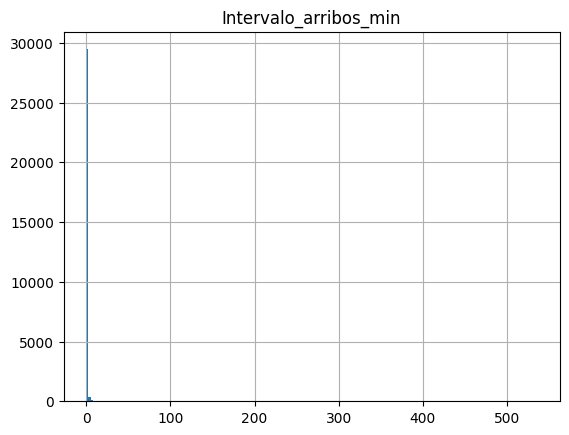

In [ ]:
datos.hist('Intervalo_arribos_min',bins=200)

<Axes: >

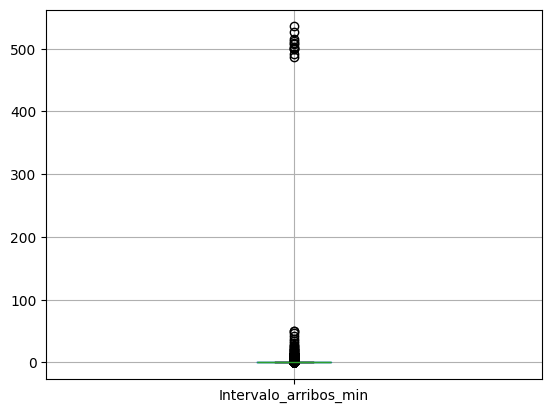

In [ ]:
datos.boxplot('Intervalo_arribos_min')

#####Consederamos los valores altos la diferencia entre llegadas de dias diferentes. No seran tenidos en cuenta.

In [ ]:
datos_filtrados = datos[datos['Intervalo_arribos_min'] < 100]

array([[<Axes: title={'center': 'Intervalo_arribos_min'}>]], dtype=object)

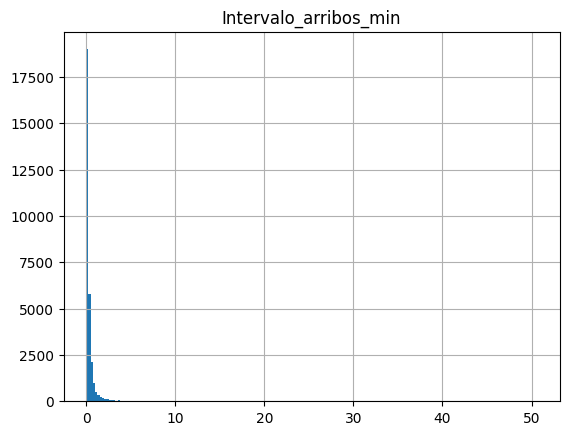

In [ ]:
datos_filtrados.hist('Intervalo_arribos_min',bins=200)

Procedemos a acotar los valores.

In [ ]:
datos_filtrados = datos_filtrados[datos_filtrados['Intervalo_arribos_min'] < 10]

array([[<Axes: title={'center': 'Intervalo_arribos_min'}>]], dtype=object)

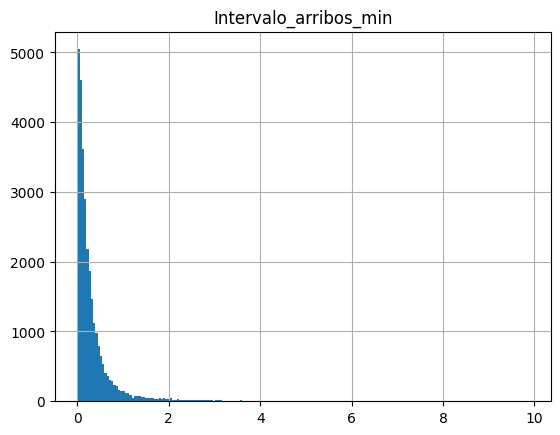

In [ ]:
datos_filtrados.hist('Intervalo_arribos_min',bins=200)

In [ ]:
datos_filtrados = datos_filtrados[datos_filtrados['Intervalo_arribos_min'] < 2]

array([[<Axes: title={'center': 'Intervalo_arribos_min'}>]], dtype=object)

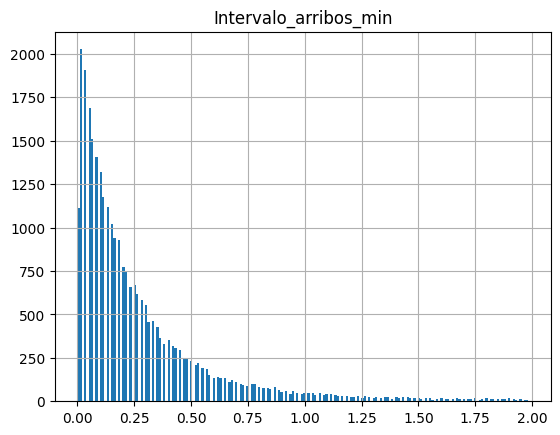

In [ ]:
datos_filtrados.hist('Intervalo_arribos_min',bins=200)

###Histogramas finales.
#####En orden, tiempo de atencion de titulares, tiempo de atencion e suplentes, tiempo entre arribos

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

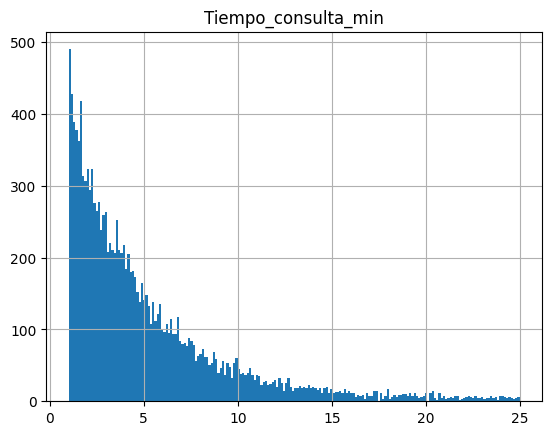

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

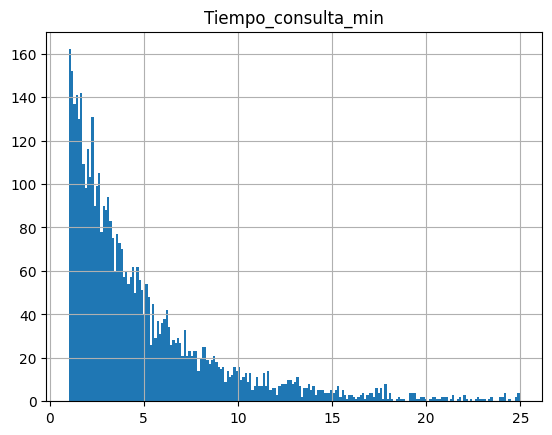

In [ ]:
datos_sustitutos_filtrados.hist('Tiempo_consulta_min',bins=200)

array([[<Axes: title={'center': 'Intervalo_arribos_min'}>]], dtype=object)

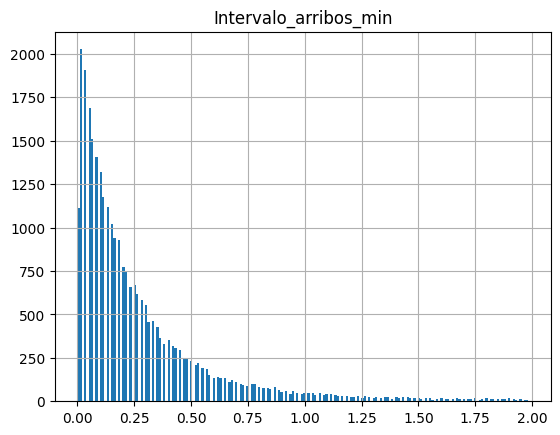

In [ ]:
datos_filtrados.hist('Intervalo_arribos_min',bins=200)

###Creamos fdp

In [ ]:
fdp_TAT = Fitter(datos_titulares_filtrados.Tiempo_consulta_min)

In [ ]:
fdp_TAT.fit()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
f,0.001714,66978.150462,67008.294912,0.005846,0.008922,0.218871
exponweib,0.001736,66925.150905,66955.295356,0.007866,0.012472,0.026671
pearson3,0.001757,67011.674391,67034.282729,0.008417,0.015058,0.003703
genhyperbolic,0.001785,67117.738300,67155.418863,0.007035,0.973648,0.000000
beta,0.001836,66862.595516,66892.739967,0.007291,0.009274,0.183331
gengamma,0.001905,66980.958138,67011.102589,0.006268,0.015309,0.002999
halfgennorm,0.002051,67210.014430,67232.622769,0.006647,0.008659,0.248721
weibull_min,0.002092,67060.119276,67082.727614,0.007020,0.016682,0.000887
gamma,0.002099,66888.016247,66910.624585,0.007138,0.020382,0.000020
truncpareto,0.002130,66999.876325,67030.020776,0.004910,0.011026,0.068403


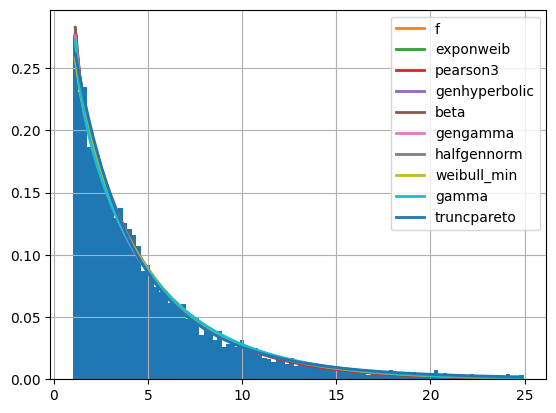

In [ ]:
fdp_TAT.summary(10)

In [ ]:
fdp_TAS = Fitter(datos_sustitutos_filtrados.Tiempo_consulta_min)

In [ ]:
fdp_TAS.fit()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
genpareto,0.003328,21406.653840,21425.926441,0.018904,0.006801,0.983446
truncpareto,0.003350,21343.446315,21369.143116,0.022208,0.009083,0.843062
burr12,0.003364,21400.909918,21426.606720,0.017675,0.009812,0.768826
halfgennorm,0.003366,21390.998539,21410.271140,0.017568,0.010088,0.738670
gengamma,0.003597,21365.981233,21391.678034,0.018129,0.017232,0.132079
pareto,0.003701,21398.898976,21418.171577,0.017828,0.011493,0.579945
lomax,0.003701,21398.898976,21418.171577,0.017828,0.011493,0.579936
weibull_min,0.003771,21340.913537,21360.186138,0.017632,0.011675,0.559638
geninvgauss,0.003802,21409.502834,21435.199635,0.017542,0.015462,0.223796
genhyperbolic,0.003871,21385.029707,21417.150709,0.017602,0.964442,0.000000


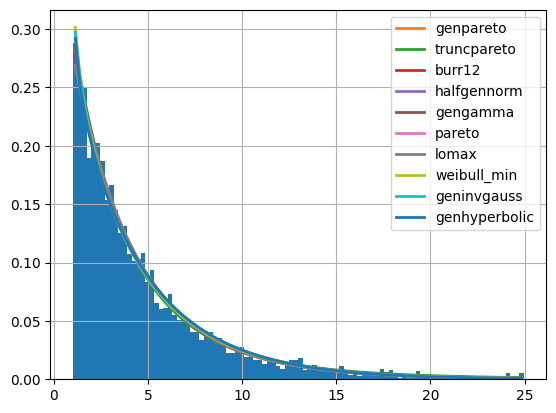

In [ ]:
fdp_TAS.summary(10)

In [ ]:
fdp_IA = Fitter(datos_filtrados.Intervalo_arribos_min)

In [ ]:
fdp_IA.fit()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,7.169380,-36849.605237,-36816.486181,0.045396,0.053501,6.307081e-73
gengamma,7.262681,-43795.399721,-43762.280665,0.046856,0.049076,2.001824e-61
chi2,7.549064,-31410.717673,-31385.878381,0.045559,0.041245,1.660918e-43
halfgennorm,7.624578,-18779.761541,-18754.922249,0.039067,0.043004,2.931727e-47
pareto,8.130461,-18654.993055,-18630.153763,0.039895,0.038199,2.238320e-37
genpareto,8.133911,-18654.929513,-18630.090221,0.039897,0.038198,2.245616e-37
gamma,8.138836,-44807.347320,-44782.508028,0.048518,0.067886,3.389509e-117
truncpareto,8.234349,-18965.380848,-18932.261791,0.039907,0.039061,4.606149e-39
lomax,8.893656,-17499.540404,-17474.701112,0.042073,0.060450,5.333647e-93
loglaplace,8.975500,-36451.611209,-36426.771917,0.048119,0.075980,9.724060e-147


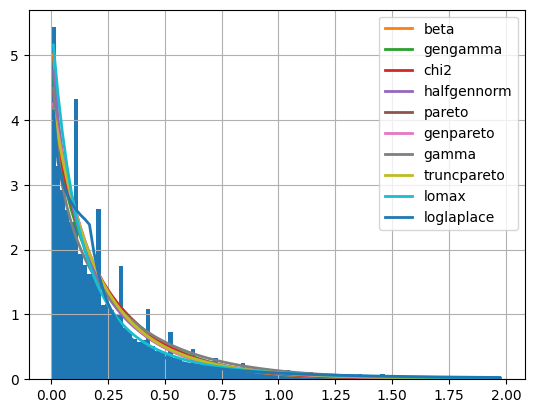

In [ ]:
fdp_IA.summary(10)

###Simulamos un set de datos para cada variable.

#####Intervalo entre arribos

In [ ]:
fdp_IA.get_best(method='sumsquare_error')

{'beta': {'a': np.float64(0.8506787350048977),
  'b': np.float64(119.16563440533798),
  'loc': np.float64(-5.039976276199166e-28),
  'scale': np.float64(34.07584894426459)}}

In [ ]:
a_IA = np.float64(0.8506787350048977)
b_IA = np.float64(119.16563440533798)
loc_IA = np.float64(-5.039976276199166e-28)
scale_IA = np.float64(34.07584894426459)

In [ ]:
fdp_IA_beta = stats.beta.rvs(a_IA, b_IA, loc=loc_IA, scale=scale_IA ,size=30000)

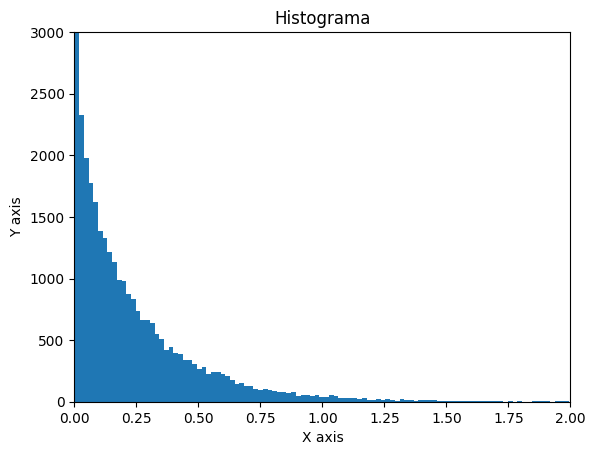

In [ ]:
# Histograma de datos de verificación
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0, 2)
plt.ylim(0, 3000)
plt.hist(fdp_IA_beta, bins=150)
plt.show()

array([[<Axes: title={'center': 'Intervalo_arribos_min'}>]], dtype=object)

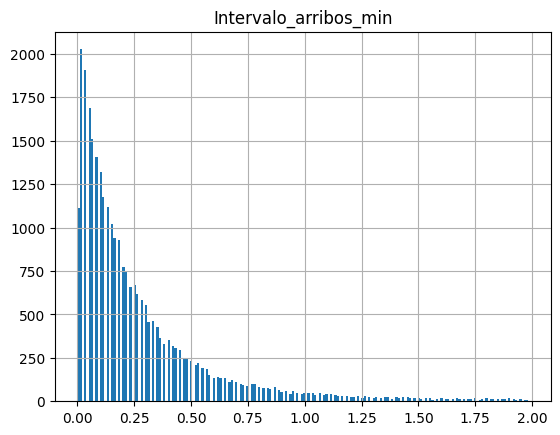

In [ ]:
datos_filtrados.hist('Intervalo_arribos_min',bins=200)

#####Tiempo de atencion titulares

In [ ]:
fdp_TAT.get_best(method='sumsquare_error')

{'f': {'dfn': np.float64(1.8565442689118927),
  'dfd': np.float64(38.61216990606688),
  'loc': np.float64(1.016666666666666),
  'scale': np.float64(4.023906662604354)}}

In [ ]:
dfn_TAT = np.float64(1.8565442689118927)
dfd_TAT = np.float64(38.61216990606688)
loc_TAT = np.float64(1.016666666666666)
scale_TAT = np.float64(4.023906662604354)

In [ ]:
fdp_TAT_f = stats.f.rvs(dfn_TAT, dfd_TAT, loc=loc_TAT, scale=scale_TAT, size=30000)

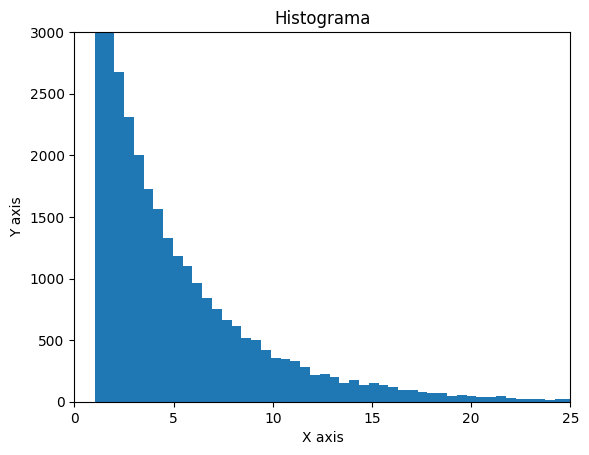

In [ ]:
# Histograma de datos de verificación
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0, 25)
plt.ylim(0, 3000)
plt.hist(fdp_TAT_f, bins=150)
plt.show()

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

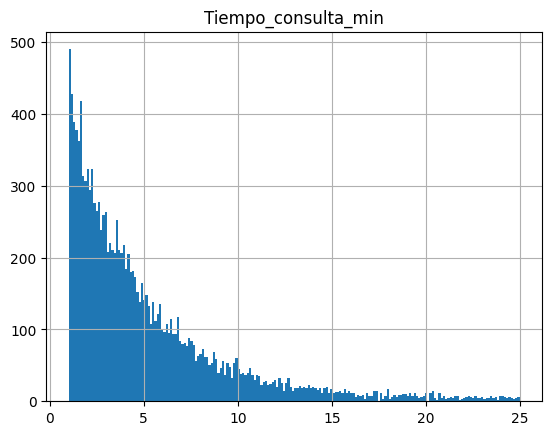

In [ ]:
datos_titulares_filtrados.hist('Tiempo_consulta_min',bins=200)

#####Tiempo de atencion Suplentes

In [ ]:
fdp_TAS.get_best(method='sumsquare_error')

{'genpareto': {'c': np.float64(0.118507044920764),
  'loc': np.float64(1.0166666660287709),
  'scale': np.float64(3.4662681374907205)}}

In [ ]:
c_TAS = np.float64(0.118507044920764)
loc_TAS = np.float64(1.0166666660287709)
scale_TAS = np.float64(3.4662681374907205)

In [ ]:
fdp_TAS_genpareto = stats.genpareto.rvs(c_TAS, loc=loc_TAS, scale=scale_TAS,size = 30000)

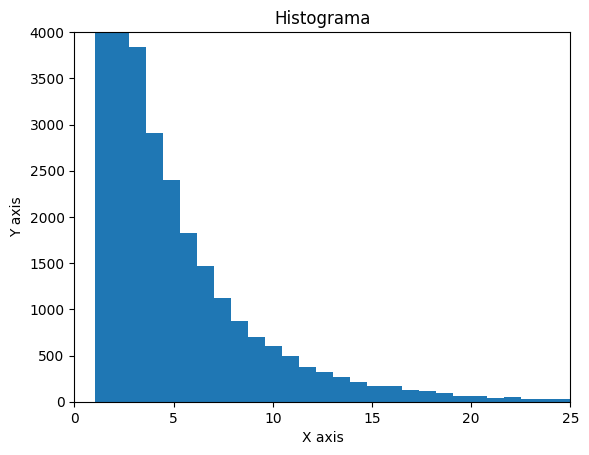

In [ ]:
# Histograma de datos de verificación
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0, 25)
plt.ylim(0, 4000)
plt.hist(fdp_TAS_genpareto, bins=150)
plt.show()

array([[<Axes: title={'center': 'Tiempo_consulta_min'}>]], dtype=object)

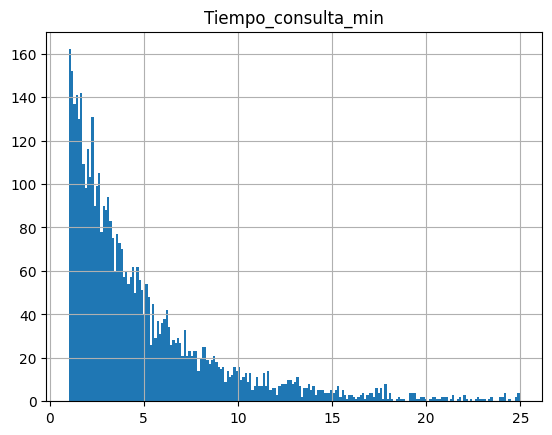

In [ ]:
datos_sustitutos_filtrados.hist('Tiempo_consulta_min',bins=200)

####Por ultimo analizaremos si existe una diferencia significativa entre el tiempo de atencion de titulares y suplentes. Asi definiremos si tiene sentido usar dos variables aleatorias.

#####Usaremos el test de Kolmogorov-Smirnov. Si el resultado de este es 0 son la misma distribucion, si es 1 son completamente diferentes.

In [ ]:
ks_stat, p_value = stats.ks_2samp(fdp_TAS_genpareto, fdp_TAT_f)

print("KS statistic:", ks_stat)
print("p-value:", p_value)

KS statistic: 0.03653333333333331
p-value: 7.873392063207237e-18


#####Como vemos los valores obtenidos son muy cercanos a cero. Por lo que definiremos a fdp_TAT como representativa de todo el tiempo de atencion. Elegimos esta por tener la muestra mas grande.

###Conclusión.

A lo largo de este trabajo se procesó y analizó el conjunto de datos correspondientes a la atención de los pacientes en un hospital. Inicialmente se descubrió inconsistencias en algunos datos, como tiempos negativos o valores no comunes, los cuales fueron filtrados para obtener muestras representativas.

 Posteriormente, se construyeron variables relevantes para la simulación, como el tiempo de atención y los intervalos entre arribos de los pacientes. A partir de estas variables se analizaron sus distribuciones mediante histogramas.

 Se aplicaron técnicas de ajuste de funciones de densidad de probabilidad (FDP) utilizando la libreria Fitter, obteniendo como mejores aproximaciones una distribución Beta para los intervalos entre arribos, una distribución F para los tiempos de atención de medicos titulares, y una distribución Generalized para los médicos suplentes.

 Con las funciones de densidad obtenidas generamos los datos simulados y pudimos verificar mediante histogramas que sus valores se ajustan a la forma de los datos originales, lo cual demuestra su validación.

 En conclusión, el trabajo permitió obtener modelos probabilísticos representativos del sistema real.